In [ ]:
import numpy as np
model_2br_1 = np.load("./data/steel_solidification/model_s-don_1.npz")
print(model_2br_1.files)

['a', 'b', 'c', 'd']


In [2]:
predictions = model_2br_1['d']
predictions = predictions[:, ::2]
targets = model_2br_1['b']
targets= targets[:, ::2]
print(predictions.shape)
print(targets.shape)

(1000, 301)
(1000, 301)


In [3]:
"""
# Example numpy arrays for prediction and target
# Replace these with your actual arrays
np.random.seed(42)  # For reproducibility
num_samples = 100
num_features = 5

predictions = np.random.rand(num_samples, num_features)
targets = np.random.rand(num_samples, num_features)
"""

# Calculate L2 for each sample
###mae_per_sample = np.mean(np.abs(predictions - targets), axis=1)
l2_per_sample_stress_sdon =  np.linalg.norm( targets - predictions, axis=1) / (np.linalg.norm(targets, axis=1) + 1e-8)

# Find indices for the smallest, medium, and 85% largest MAE
sorted_indices = np.argsort(l2_per_sample_stress_sdon)
smallest_mae_index = sorted_indices[0]
medium_mae_index = sorted_indices[len(sorted_indices) // 2]
large_index = sorted_indices[int(len(sorted_indices) * 0.98)]
small_index = sorted_indices[int(len(sorted_indices) * 0.10)]
medium_index = sorted_indices[int(len(sorted_indices) * 0.55)]

# Extract values and indexes
smallest_mae_value = l2_per_sample_stress_sdon[smallest_mae_index]
medium_mae_value = l2_per_sample_stress_sdon[medium_mae_index]
large_value = l2_per_sample_stress_sdon[large_index]
small_value = l2_per_sample_stress_sdon[small_index]
medium_value = l2_per_sample_stress_sdon[medium_index]

# Print results
print(f"Smallest MAE: Value = {smallest_mae_value}, Index = {smallest_mae_index}")
print(f"Medium MAE: Value = {medium_mae_value}, Index = {medium_mae_index}")
print(f"10% Small MAE: Value = {small_value}, Index = {small_index}")
print(f"50% Medium MAE: Value = {medium_value}, Index = {medium_index}")
print(f"99% Largest MAE: Value = {large_value}, Index = {large_index}")



Smallest MAE: Value = 0.03181758531809891, Index = 958
Medium MAE: Value = 0.13036395504895992, Index = 756
10% Small MAE: Value = 0.06638931766782817, Index = 428
50% Medium MAE: Value = 0.14301743601906833, Index = 487
99% Largest MAE: Value = 0.5545541759601051, Index = 21


In [4]:
print(np.mean(np.abs(predictions[large_index] - targets[large_index])))

114686.04237220377


In [ ]:
model_1br_infer_2br_1 = np.load("./data/steel_solidification/s-not_slice_results.npz")
predictions_1br = model_1br_infer_2br_1['d']
predictions_1br = predictions_1br[:, ::2]
targets_1br = model_1br_infer_2br_1['b']
targets_1br = targets_1br[:, ::2]
print(np.mean(np.abs(predictions_1br[smallest_mae_index] - targets_1br[smallest_mae_index])))
print(np.mean(np.abs(predictions_1br[medium_mae_index] - targets_1br[medium_mae_index])))
print(np.mean(np.abs(predictions_1br[large_index] - targets_1br[large_index])))

18298.107
11090.073
17586.088


In [6]:
combined_targets = np.column_stack((targets[large_index], targets_1br[large_index]))
print(combined_targets)

[[ 4.16249156e+05  4.16249156e+05]
 [ 8.29668203e+04  8.29668203e+04]
 [-2.34524937e+05 -2.34524922e+05]
 [-5.34506125e+05 -5.34506125e+05]
 [-8.16668000e+05 -8.16668062e+05]
 [-1.08168400e+06 -1.08168400e+06]
 [-1.32856412e+06 -1.32856412e+06]
 [-1.55601413e+06 -1.55601412e+06]
 [-1.75998088e+06 -1.75998088e+06]
 [-1.94490412e+06 -1.94490425e+06]
 [-2.11117450e+06 -2.11117450e+06]
 [-2.25929200e+06 -2.25929200e+06]
 [-2.38894775e+06 -2.38894775e+06]
 [-2.50095275e+06 -2.50095275e+06]
 [-2.59937550e+06 -2.59937550e+06]
 [-2.58965500e+06 -2.58965500e+06]
 [-1.62546362e+06 -1.62546362e+06]
 [-6.87014609e+04 -6.87014609e+04]
 [ 2.04155613e+06  2.04155612e+06]
 [ 2.89499075e+06  2.89499075e+06]
 [ 3.22914425e+06  3.22914425e+06]
 [ 3.82825525e+06  3.82825525e+06]
 [ 4.17616225e+06  4.17616225e+06]
 [ 3.30775225e+06  3.30775225e+06]
 [ 1.69458525e+06  1.69458525e+06]
 [ 3.94793719e+05  3.94793719e+05]
 [ 3.89457125e+05  3.89457125e+05]
 [ 3.79103531e+05  3.79103531e+05]
 [ 3.73713594e+05  3

In [7]:
x = np.linspace(0, 30, 301)

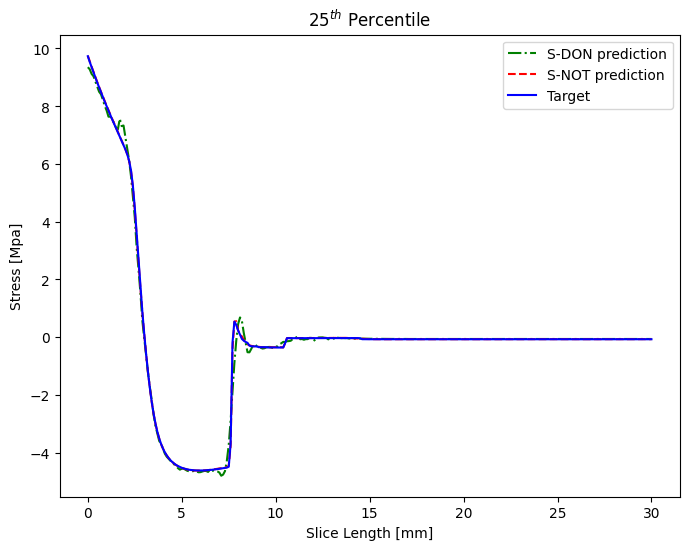

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(x, predictions[small_index]/1000000., label='S-DON prediction', color='Green', linestyle='-.')
plt.plot(x, predictions_1br[small_index]/1000000., label='S-NOT prediction', color='Red', linestyle='--')
plt.plot(x, targets[small_index]/1000000., label='Target', color='Blue')

# Add labels and legend
plt.xlabel('Slice Length [mm]')
plt.ylabel('Stress [Mpa]')
plt.title('25$^{th}$ Percentile')
plt.legend()
plt.savefig('stress_25th.jpg', format='jpg', dpi=300)
#plt.grid(True)

# Show the plot
plt.show()

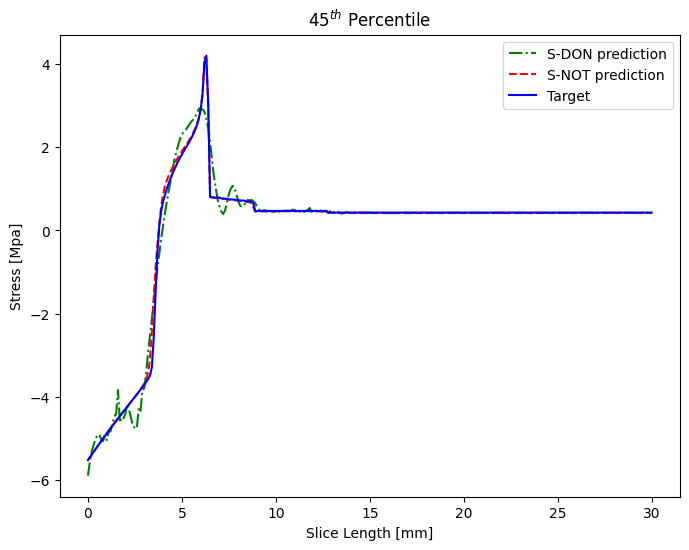

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(x, predictions[medium_index]/1000000., label='S-DON prediction', color='Green', linestyle='-.')
plt.plot(x, predictions_1br[medium_index]/1000000., label='S-NOT prediction', color='Red', linestyle='--')
plt.plot(x, targets[medium_index]/1000000., label='Target', color='Blue')

# Add labels and legend
plt.xlabel('Slice Length [mm]')
plt.ylabel('Stress [Mpa]')
plt.title('45$^{th}$ Percentile')
plt.legend()
plt.savefig('stress_50th.jpg', format='jpg', dpi=300)
#plt.grid(True)

# Show the plot
plt.show()

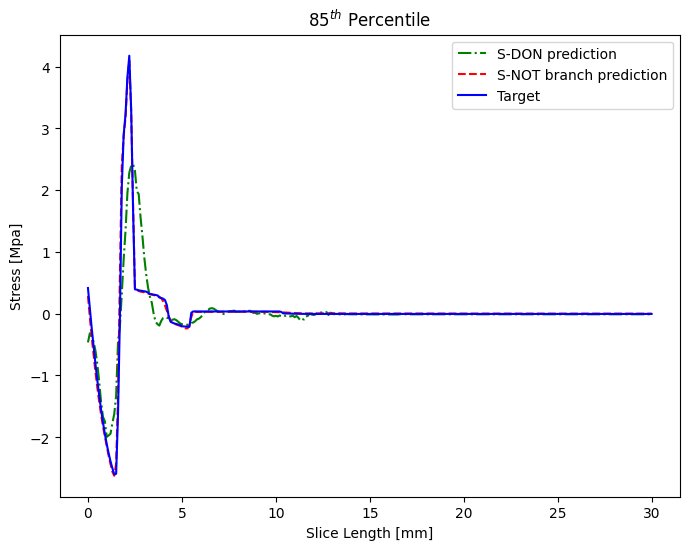

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(x, predictions[large_index]/1000000., label='S-DON prediction', color='Green', linestyle='-.')
plt.plot(x, predictions_1br[large_index]/1000000., label='S-NOT branch prediction', color='Red', linestyle='--')
plt.plot(x, targets[large_index]/1000000., label='Target', color='Blue')

# Add labels and legend
plt.xlabel('Slice Length [mm]')
plt.ylabel('Stress [Mpa]')
plt.title('85$^{th}$ Percentile')
plt.legend()
plt.savefig('stress_85th.jpg', format='jpg', dpi=300)
#plt.grid(True)

# Show the plot
plt.show()



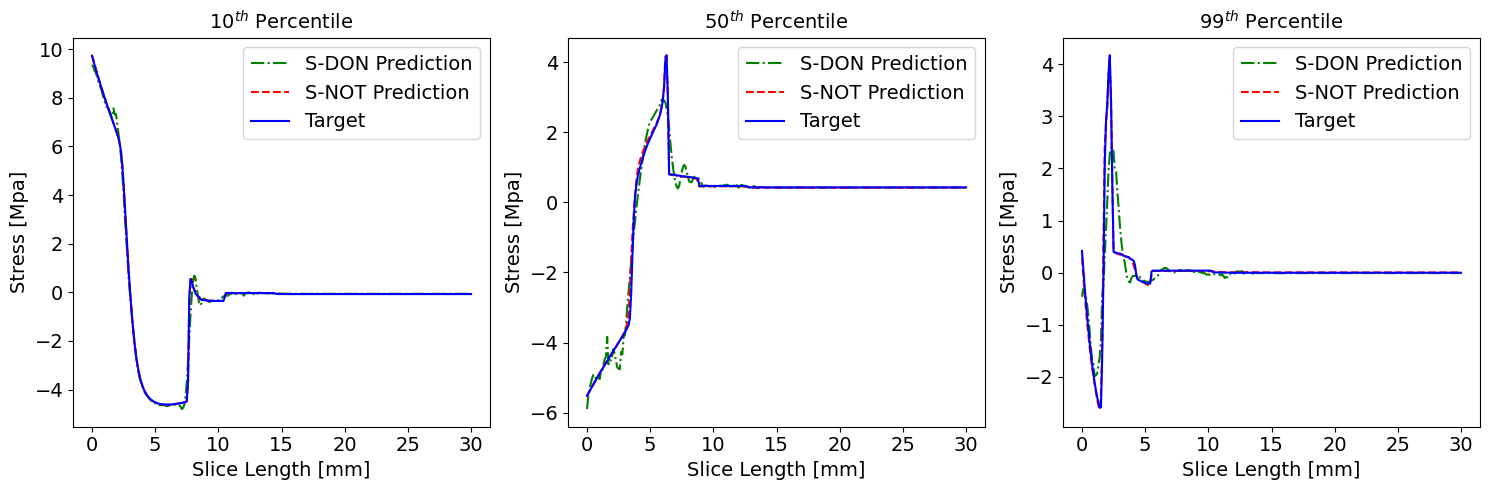

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
font_size = 14
axes[0].plot(x, predictions[small_index]/1000000., label='S-DON Prediction', color='Green', linestyle='-.')
axes[0].plot(x, predictions_1br[small_index]/1000000., label='S-NOT Prediction', color='Red', linestyle='--')
axes[0].plot(x, targets[small_index]/1000000., label='Target', color='Blue')
axes[0].set_title('10$^{th}$ Percentile', fontsize=font_size)  # Title for the first plot
axes[0].set_xlabel('Slice Length [mm]', fontsize=font_size)  # X-axis label
axes[0].set_ylabel('Stress [Mpa]', fontsize=font_size)  # Y-axis label
axes[0].tick_params(axis='both', labelsize=font_size)
axes[0].legend(fontsize=font_size)
axes[1].plot(x, predictions[medium_index]/1000000., label='S-DON Prediction', color='Green', linestyle='-.')
axes[1].plot(x, predictions_1br[medium_index]/1000000., label='S-NOT Prediction', color='Red', linestyle='--')
axes[1].plot(x, targets[medium_index]/1000000., label='Target', color='Blue')
axes[1].set_title('50$^{th}$ Percentile',fontsize=font_size)  # Title for the first plot
axes[1].set_xlabel('Slice Length [mm]',fontsize=font_size)  # X-axis label
axes[1].set_ylabel('Stress [Mpa]',fontsize=font_size)  # Y-axis label
axes[1].tick_params(axis='both', labelsize=font_size)
axes[1].legend(fontsize=font_size)
axes[2].plot(x, predictions[large_index]/1000000., label='S-DON Prediction', color='Green', linestyle='-.')
axes[2].plot(x, predictions_1br[large_index]/1000000., label='S-NOT Prediction', color='Red', linestyle='--')
axes[2].plot(x, targets[large_index]/1000000., label='Target', color='Blue')
axes[2].set_title('99$^{th}$ Percentile',fontsize=font_size)  # Title for the first plot
axes[2].set_xlabel('Slice Length [mm]',fontsize=font_size)  # X-axis label
axes[2].set_ylabel('Stress [Mpa]',fontsize=font_size)  # Y-axis label
axes[2].tick_params(axis='both', labelsize=font_size)
axes[2].legend(fontsize=font_size)
# Adjust layout to prevent overlap
plt.tight_layout()
fig.savefig('stress_joined_plots_snot_sdon.jpg', format='jpeg', dpi=300)
# Show the plots
plt.show()
